In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'
os.environ["NO_ALBUMENTATIONS_UPDATE"] = '1'
os.environ['CUDA_VISIBLE_DEVICES'] = '1'

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
import tensorflow as tf
print(tf.__version__)

2.15.0


In [4]:
import keras
print(keras.__version__)

3.8.0


In [5]:
import logging
logger = tf.get_logger()
logger.setLevel(logging.ERROR)

In [6]:
import cv2
import math
import time
import shutil 
import random
import itertools
import numpy as np
import pandas as pd 
from glob import glob
import albumentations as A
from tensorflow.keras import ops
from tensorflow import keras
from functools import partial
import matplotlib.pyplot as plt
from tensorflow.keras import backend as K

In [7]:
# tf.keras.saving.get_custom_objects().clear()
# tf.keras.backend.clear_session() ## to clear other sessions in the environment
# tf.keras.mixed_precision.set_global_policy(tf.keras.mixed_precision.Policy('mixed_float16'))
tf.config.optimizer.set_jit(False) ## enabling XLA
tf.keras.config.enable_unsafe_deserialization()

In [8]:
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

# Pretraining

In [9]:
def convert(seconds):
    hour = seconds // 3600
    seconds %= 3600
    minutes = seconds // 60
    seconds %= 60     
    return "%d:%02d:%02d" % (hour, minutes, seconds)

In [10]:
tempfolder="temp_ISIC2019"
isExist = os.path.exists(tempfolder)
if not isExist:
    os.makedirs(tempfolder)

In [11]:
data_root="Datasets/2.ISIC2019/metaaug/siamese/fold1/"
output_path="./"+tempfolder+"/"

In [12]:
train_dir=data_root+"train/"
test_dir=data_root+"test/"

In [13]:
classes=sorted(os.listdir(train_dir))
print(classes)

['AK', 'BCC', 'BKL', 'DF', 'MEL', 'NV', 'SCC', 'VASC']


In [14]:
num_classes = len(os.listdir(train_dir))
num_train_images = len(glob(train_dir + '/*/*'))
num_test_images = len(glob(test_dir + '/*/*'))

print("num_classes : ", num_classes)
print("num_train_images : ", num_train_images)
print("num_test_images : ", num_test_images)

num_classes :  8
num_train_images :  1606
num_test_images :  397


In [15]:
BATCH_SIZE=32
BATCH_SIZE_SIAMESE=256
EPOCHS=300
EPOCHS_SIAMESE=100
IMG_SIZE=224
LEARNING_RATE=5e-5
dropout_rate=0.3
BUFFER_SIZE=10000
AUTO=tf.data.AUTOTUNE

In [16]:
BUFFER_SIZE=num_train_images
AUTO=tf.data.AUTOTUNE

In [17]:
def parse_image(filename, label):
    image = tf.io.read_file(filename)
    image = tf.image.decode_jpeg(image, channels=3, dct_method="INTEGER_ACCURATE")    
    image = tf.image.resize(image, (IMG_SIZE,IMG_SIZE))
    return image, label

In [18]:
file_names_train=glob(train_dir + '/*/*')
random.shuffle(file_names_train)    
lbls_train=[classes.index(name.split('/')[-2]) for name in file_names_train]
lbls_train_one_hot = tf.one_hot(lbls_train, depth=num_classes)
train_dataset=tf.data.Dataset.from_tensor_slices((file_names_train, lbls_train_one_hot))

In [19]:
train_dataset=(
    train_dataset
    .shuffle(buffer_size=BUFFER_SIZE)
    .map(parse_image, num_parallel_calls=AUTO) 
    .batch(BATCH_SIZE)
    .prefetch(buffer_size=AUTO)
)

In [20]:
file_names_test=glob(test_dir + '/*/*')    
lbls_test=[classes.index(name.split('/')[-2]) for name in file_names_test]
lbls_test_one_hot = tf.one_hot(lbls_test, depth=num_classes)
test_dataset=tf.data.Dataset.from_tensor_slices((file_names_test, lbls_test_one_hot))

In [21]:
test_dataset=(
    test_dataset    
    .map(parse_image, num_parallel_calls=AUTO)
    .batch(BATCH_SIZE)
    .prefetch(buffer_size=AUTO)
)

In [22]:
tr_lb=np.array(lbls_train)
tr_lb_unique=np.unique(tr_lb)
print((np.unique(tr_lb, return_counts=True)))

(array([0, 1, 2, 3, 4, 5, 6, 7]), array([105, 268, 231,  39, 324, 516,  83,  40]))


In [23]:
from sklearn.utils import compute_class_weight
#formula: n_samples / (n_classes * np.bincount(y))
classWeight=compute_class_weight(class_weight="balanced",classes=tr_lb_unique,y=tr_lb)
classWeight=np.round(classWeight,4)
classWeight_dict = dict(zip(tr_lb_unique, classWeight))
print("classWeight : ",classWeight_dict)

classWeight :  {0: 1.9119, 1: 0.7491, 2: 0.869, 3: 5.1474, 4: 0.6196, 5: 0.3891, 6: 2.4187, 7: 5.0188}


In [24]:
base_model=tf.keras.applications.EfficientNetB0(include_top=False, weights='imagenet', input_shape=(IMG_SIZE,IMG_SIZE,3))
base_model.trainable=False

In [25]:
@tf.keras.utils.register_keras_serializable(package="Custom", name="SpatialAttention")
class SpatialAttention(tf.keras.layers.Layer):
    def __init__(self, kernel_size=3, **kwargs):
        super(SpatialAttention, self).__init__(**kwargs)
        self.kernel_size = kernel_size
        self.conv = tf.keras.layers.Conv2D(1, kernel_size, padding='same', activation='sigmoid')

    def call(self, inputs):
        avg_out = tf.keras.backend.mean(inputs, axis=-1, keepdims=True)
        max_out = tf.keras.backend.max(inputs, axis=-1, keepdims=True)
        concat = tf.keras.backend.concatenate([avg_out, max_out], axis=-1)
        attention_weights = self.conv(concat)
        return inputs * attention_weights

    def get_config(self):
        config = super().get_config()
        config.update({"kernel_size": self.kernel_size})
        return config

In [26]:
x = SpatialAttention()(base_model.output)
x = tf.keras.layers.GlobalAveragePooling2D(name="global_avg_pool")(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(dropout_rate, name="dropout1")(x)
x = tf.keras.layers.Dense(512, activation="silu", name="pred1")(x) 
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(dropout_rate, name="dropout2")(x)
x = tf.keras.layers.Dense(128, activation="silu", name="pred2")(x) 
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(dropout_rate, name="dropout3")(x)
output = tf.keras.layers.Dense(num_classes, activation="softmax", name="pred3")(x) 
embedding_network = tf.keras.Model(base_model.input, output, name="Embedding_EfficientNetB0")

In [27]:
for layer in embedding_network.layers:
    layer.trainable = True

In [28]:
optimizer_fn = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE, clipnorm=2.0)  
metrics = [tf.keras.metrics.CategoricalAccuracy(name='accuracy')]
loss_fn = tf.keras.losses.CategoricalFocalCrossentropy(gamma=5, label_smoothing=0.05)

embedding_network.compile(optimizer = optimizer_fn, loss = loss_fn, metrics = metrics)

In [29]:
model_name_1=output_path+"embedding_network.weights.h5"
ModelCheckPoint1=tf.keras.callbacks.ModelCheckpoint(filepath=model_name_1,
    monitor='val_accuracy', verbose=1, save_best_only=True, save_weights_only=True)

In [30]:
%%time
t1=time.time()
history = embedding_network.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=classWeight_dict,
    callbacks=[ModelCheckPoint1] 
)
t2=time.time()
time_taken = t2-t1
print("Time taken : ",convert(time_taken)," hh:mm:ss")

Epoch 1/300
 1/51 ━━━━━━━━━━━━━━━━━━━━ 1:08:50 83s/step - accuracy: 0.0938 - loss: 0.7500

I0000 00:00:1741497398.952828  926500 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1445 - loss: 0.6163  
Epoch 1: val_accuracy improved from -inf to 0.15617, saving model to ./temp_ISIC2019/embedding_network.weights.h5
51/51 ━━━━━━━━━━━━━━━━━━━━ 147s 1s/step - accuracy: 0.1446 - loss: 0.6163 - val_accuracy: 0.1562 - val_loss: 0.2899
Epoch 2/300
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.1704 - loss: 0.4930
Epoch 2: val_accuracy improved from 0.15617 to 0.19395, saving model to ./temp_ISIC2019/embedding_network.weights.h5
51/51 ━━━━━━━━━━━━━━━━━━━━ 4s 76ms/step - accuracy: 0.1704 - loss: 0.4926 - val_accuracy: 0.1940 - val_loss: 0.2875
Epoch 3/300
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.2130 - loss: 0.4269
Epoch 3: val_accuracy improved from 0.19395 to 0.24937, saving model to ./temp_ISIC2019/embedding_network.weights.h5
51/51 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step - accuracy: 0.2132 - loss: 0.4267 - val_accuracy: 0.2494 - val_loss: 0.2736
Epoch 4/300
50/51 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accu

In [31]:
embedding_network.load_weights(model_name_1)

In [32]:
test_loss, test_accuracy_by_evaluate = embedding_network.evaluate(test_dataset)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7358 - loss: 0.1040


In [33]:
test_accuracy_by_evaluate_rounded = round((test_accuracy_by_evaluate)*100, 2)

In [34]:
print(test_accuracy_by_evaluate_rounded)

65.99


# Load Siamese Data

In [35]:
end = '_ISIC2019_Siamese'
destination='Results/siamese/2.ISIC2019/'

train_csv_file="fold1_train.csv" 
test_csv_file="fold1_test.csv" 

output_filename_train_genuine = "ISIC2019_siamese_train_genuine_pairs.csv"
output_filename_train_imposter = "ISIC2019_siamese_train_imposter_pairs.csv"  

output_filename_test_genuine = "ISIC2019_siamese_test_genuine_pairs.csv"
output_filename_test_imposter = "ISIC2019_siamese_test_imposter_pairs.csv"  

data_root="Datasets/2.ISIC2019/metaaug/siamese/fold1/"
path="Datasets/2.ISIC2019/"
output_path="./"+tempfolder+"/"

In [36]:
train_data=[]

In [37]:
genuine_train=np.array(pd.read_csv(data_root+output_filename_train_genuine, names=["0","1","2"], header=None))
for i in range(genuine_train.shape[0]):
    image1=genuine_train[i][0]
    image2=genuine_train[i][1]
    label=genuine_train[i][2]    
    train_data.append([image1, image2, label])

In [38]:
imposter_train=np.array(pd.read_csv(data_root+output_filename_train_imposter, names=["0","1","2"], header=None))
for i in range(imposter_train.shape[0]):
    image1=imposter_train[i][0]
    image2=imposter_train[i][1]
    label=imposter_train[i][2]    
    train_data.append([image1, image2, label])

In [39]:
test_data=[]

In [40]:
genuine_test=np.array(pd.read_csv(data_root+output_filename_test_genuine, names=["0","1","2"], header=None))
for i in range(genuine_test.shape[0]):
    image1=genuine_test[i][0]
    image2=genuine_test[i][1]
    label=genuine_test[i][2]    
    test_data.append([image1, image2, label])

In [41]:
imposter_test=np.array(pd.read_csv(data_root+output_filename_test_imposter, names=["0","1","2"], header=None))
for i in range(imposter_test.shape[0]):
    image1=imposter_test[i][0]
    image2=imposter_test[i][1]
    label=imposter_test[i][2]    
    test_data.append([image1, image2, label])

In [42]:
train_data=np.array(train_data)
test_data=np.array(test_data)

In [43]:
np.random.shuffle(train_data)
np.random.shuffle(test_data)

In [44]:
train_data_pair=train_data[:, :2]
train_data_label=train_data[:, 2]
test_data_pair=test_data[:, :2]
test_data_label=test_data[:, 2]

In [45]:
train_data_label=np.int16(train_data_label)
test_data_label=np.int16(test_data_label)

In [46]:
print(train_data.shape, test_data.shape)

(515846, 3) (31382, 3)


In [47]:
def preprocess_image(file_path, label):
    def load_and_preprocess(file_path):        
        image = tf.io.read_file(path + file_path)
        image = tf.image.decode_jpeg(image, channels=3, dct_method="INTEGER_ACCURATE")
        image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE), method='area')
        return image

    image_a = load_and_preprocess(file_path[0])
    image_b = load_and_preprocess(file_path[1])
    
    return (image_a, image_b), label

In [48]:
def create_tf_train_dataset(file_paths, labels, batch_size):
    dataset = tf.data.Dataset.from_tensor_slices((file_paths, labels))
    dataset = dataset.shuffle(buffer_size=BUFFER_SIZE)
    dataset = dataset.map(lambda x, y: preprocess_image(x, y), num_parallel_calls=AUTO)
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(buffer_size=AUTO)
    return dataset

train_ds=create_tf_train_dataset(train_data_pair, train_data_label, BATCH_SIZE_SIAMESE)

In [49]:
def create_tf_test_dataset(file_paths, labels, batch_size):
    dataset = tf.data.Dataset.from_tensor_slices((file_paths, labels))
    dataset = dataset.shuffle(buffer_size=BUFFER_SIZE)
    dataset = dataset.map(lambda x, y: preprocess_image(x, y), num_parallel_calls=AUTO)
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(buffer_size=AUTO)
    return dataset

test_ds=create_tf_test_dataset(test_data_pair, test_data_label, BATCH_SIZE_SIAMESE)

# Train

In [50]:
layer_index = [i for i, layer in enumerate(embedding_network.layers) if layer.name == "block6a_expand_conv"][0]
for layer in embedding_network.layers[:layer_index]:
    layer.trainable = False
    
for layer in embedding_network.layers[layer_index:]:
    layer.trainable = True

In [51]:
@tf.keras.utils.register_keras_serializable(package="Custom", name="euclidean_distance")
def euclidean_distance(vects):
    x, y = vects
    return tf.expand_dims(tf.norm(x - y, axis=1), axis=-1)  # Ensures (batch_size, 1)

# Siamese Network Inputs
input_1 = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
input_2 = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

# Pass inputs through embedding network
tower_1 = embedding_network(input_1)
tower_2 = embedding_network(input_2)

merge_layer = keras.layers.Lambda(euclidean_distance, output_shape=(1,))([tower_1, tower_2])
normal_layer = keras.layers.BatchNormalization(name="batch_norm")(merge_layer)
output_layer = keras.layers.Dense(1, activation="sigmoid", name="output")(normal_layer)
siamese = keras.Model(inputs=[input_1, input_2], outputs=output_layer)

In [52]:
@tf.keras.utils.register_keras_serializable("contrastiveloss")
def contrastiveloss(margin=0.3):
    # Contrastive loss = mean( (1-true_value) * square(prediction) + true_value * square( max(margin-prediction, 0) ))
    def contrastive_loss(y_true, y_pred):
        square_pred = ops.square(y_pred)
        margin_square = ops.square(ops.maximum(margin - (y_pred), 0))
        return ops.mean((1 - y_true) * square_pred + (y_true) * margin_square)

    return contrastive_loss

In [53]:
siamese.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE, clipnorm=2.0),  
    loss=contrastiveloss(), 
    metrics=["accuracy"]
)

In [54]:
model_name2=output_path+"siamese_model.weights.h5"
ModelCheckPoint2=tf.keras.callbacks.ModelCheckpoint(filepath=model_name2,
    monitor='val_accuracy', verbose=1, save_best_only=True, save_weights_only=True)

In [55]:
t1=time.time()
history=siamese.fit(
    train_ds, 
    validation_data=test_ds,  
    batch_size=BATCH_SIZE_SIAMESE,
    epochs=EPOCHS_SIAMESE,
    class_weight=classWeight_dict,
    callbacks=[ModelCheckPoint2] 
)
t2=time.time()
time_taken = t2-t1
print("Time taken : ", convert(time_taken), " hh:mm:ss")

Epoch 1/100
2016/2016 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.9860 - loss: 0.1035
Epoch 1: val_accuracy improved from -inf to 0.71289, saving model to ./temp_ISIC2019/siamese_model.weights.h5
2016/2016 ━━━━━━━━━━━━━━━━━━━━ 497s 205ms/step - accuracy: 0.9860 - loss: 0.1035 - val_accuracy: 0.7129 - val_loss: 0.1010
Epoch 2/100
2015/2016 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.9997 - loss: 0.0688
Epoch 2: val_accuracy improved from 0.71289 to 0.71726, saving model to ./temp_ISIC2019/siamese_model.weights.h5
2016/2016 ━━━━━━━━━━━━━━━━━━━━ 350s 173ms/step - accuracy: 0.9997 - loss: 0.0688 - val_accuracy: 0.7173 - val_loss: 0.0883
Epoch 3/100
2015/2016 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.9997 - loss: 0.0440
Epoch 3: val_accuracy improved from 0.71726 to 0.72583, saving model to ./temp_ISIC2019/siamese_model.weights.h5
2016/2016 ━━━━━━━━━━━━━━━━━━━━ 346s 172ms/step - accuracy: 0.9997 - loss: 0.0440 - val_accuracy: 0.7258 - val_loss: 0.0757
Epoch 4/100
2015/2016 

In [56]:
Hist = {'hist' : history.history} 
df = pd.DataFrame.from_dict(Hist)  
df.to_csv(output_path+'Hist.csv', index = True, header=True)  

# Save Model

In [57]:
siamese.load_weights(model_name2)

In [58]:
test_loss, test_accuracy_by_evaluate = siamese.evaluate(test_ds)

123/123 ━━━━━━━━━━━━━━━━━━━━ 17s 134ms/step - accuracy: 0.7234 - loss: 0.0760


In [59]:
test_accuracy_by_evaluate_rounded = round((test_accuracy_by_evaluate)*100, 2)

In [60]:
print(test_accuracy_by_evaluate_rounded)

72.58


In [61]:
num_epoch = len(history.history['loss'])
executed_epoch_count = len(history.history['loss'])

In [62]:
savedfilename="epochs_{}".format(executed_epoch_count)+"_test_acc_{}".format(test_accuracy_by_evaluate_rounded)

In [63]:
name=output_path+"{}".format(savedfilename)+".keras"
siamese.save(name)

In [64]:
name_weights=output_path+"{}".format(savedfilename)+".weights.h5"
siamese.save_weights(name_weights)

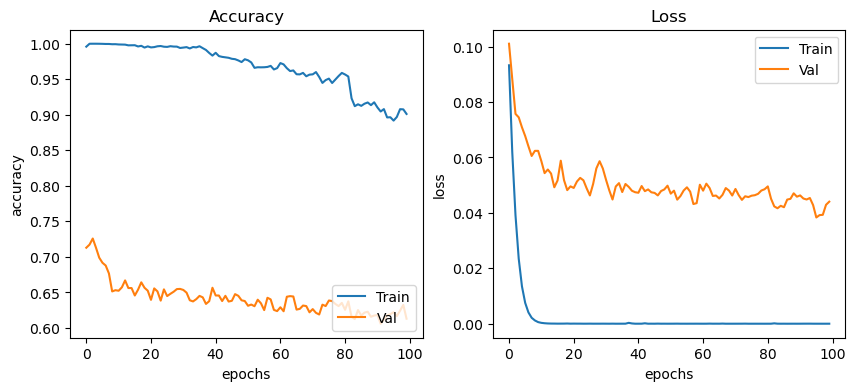

In [65]:
figpath=output_path+"{}".format(savedfilename)+".pdf"
fig = plt.figure(figsize=(10,4))
epochs_range = range(len(history.history['loss']))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history.history['accuracy'], label='Train')
plt.plot(epochs_range, history.history['val_accuracy'], label='Val')
plt.legend(loc='lower right')
plt.title('Accuracy')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history.history['loss'], label='Train')
plt.plot(epochs_range, history.history['val_loss'], label='Val')
plt.legend(loc='upper right')
plt.title('Loss')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.show()
fig.savefig(figpath, format='pdf', bbox_inches='tight')

# Predictions

In [66]:
for x in range(10):
    print(test_data_pair[x][0], test_data_pair[x][1], test_data_label[x])

metaaug/siamese/fold1/test/NV/ISIC_0029645.jpg metaaug/siamese/fold1/test/NV/ISIC_0072518.jpg 0
metaaug/siamese/fold1/test/NV/ISIC_0031363.jpg metaaug/siamese/fold1/test/NV/ISIC_0000118_downsampled.jpg 0
metaaug/siamese/fold1/test/NV/ISIC_0069941.jpg metaaug/siamese/fold1/test/DF/ISIC_0030244.jpg 1
metaaug/siamese/fold1/test/BCC/ISIC_0060288.jpg metaaug/siamese/fold1/test/MEL/ISIC_0066969.jpg 1
metaaug/siamese/fold1/test/MEL/ISIC_0054919.jpg metaaug/siamese/fold1/test/MEL/ISIC_0014316_downsampled.jpg 0
metaaug/siamese/fold1/test/MEL/ISIC_0033042.jpg metaaug/siamese/fold1/test/MEL/ISIC_0033055.jpg 0
metaaug/siamese/fold1/test/NV/ISIC_0024802.jpg metaaug/siamese/fold1/test/BKL/ISIC_0031893.jpg 1
metaaug/siamese/fold1/test/NV/ISIC_0059685.jpg metaaug/siamese/fold1/test/MEL/ISIC_0032182.jpg 1
metaaug/siamese/fold1/test/NV/ISIC_0028600.jpg metaaug/siamese/fold1/test/NV/ISIC_0024455.jpg 0
metaaug/siamese/fold1/test/NV/ISIC_0034220.jpg metaaug/siamese/fold1/test/BKL/ISIC_0033854.jpg 1


In [67]:
data_root

'Datasets/2.ISIC2019/metaaug/siamese/fold1/'

In [68]:
test_pairs=[]
l=sorted(glob(data_root+"set1_aug/*/*"))
for x in l:
    path=x
    lis=sorted(os.listdir(str(x)))
    for y in lis:
        d=x.split('/')[-1]
        f1=x+'/'+d+'_Original.png'
        f2=x+'/'+y
        test_pairs.append([f1,f2])

test_pairs=np.array(test_pairs)
df=pd.DataFrame(test_pairs)
df.to_csv(output_path+'test_pairs.csv', header=None, index=False)

In [69]:
%%time
pr=[]
pa=np.array(pd.read_csv(output_path+'test_pairs.csv', header=None))
for x in pa:
    im1=cv2.imread(x[0])
    im1=cv2.resize(im1, (IMG_SIZE,IMG_SIZE), interpolation=cv2.INTER_AREA)
    im1=np.expand_dims(im1, axis=0)
    im2=cv2.imread(x[1])
    im2=cv2.resize(im2, (IMG_SIZE,IMG_SIZE), interpolation=cv2.INTER_AREA)
    im2=np.expand_dims(im2, axis=0)
    pred=siamese.predict([im1,im2], verbose=0)
    pred=np.round(pred[0][0], 4)
    pr.append([x[0], x[1], pred])

pr=np.array(pr) 
df=pd.DataFrame(pr)
df.to_csv(output_path+'test_predictions.csv', header=None, index=False)

CPU times: user 3h 14min 22s, sys: 1h 24min 17s, total: 4h 38min 39s
Wall time: 2h 21min 2s


In [70]:
transform_list = ['AutoContrast', 'BoxBlur', 'CLAHE', 'ChannelShuffle', 'ChromaticAberration', 'CoarseDropout', 
                  'ColorJitter', 'Defocus', 'Dilation', 'ElasticTransform', 'Emboss', 'Equalize', 'EqualizeYUV', 
                  'Erosion', 'Frost', 'Gamma', 'GaussNoise', 'GaussianBlur', 'GlassBlur', 'HorizontalFlip', 
                  'HueSaturationValue', 'Invert', 'JPEGCompression', 'MedianBlur', 'MotionBlur', 'OpticalDistortion', 
                  'Original', 'Perspective', 'Posterize', 'RGBShift', 'RandomBrightnessContrast', 'RandomFog', 
                  'RandomGravel', 'RandomGridShuffle', 'RandomRain', 'RandomShadow', 'RandomSnow', 'RandomSunFlare', 
                  'RandomToneCurve', 'Rotate', 'SaltandPepper', 'Scale', 'Sharpen', 'ShearX', 'ShearY', 'ShiftScaleRotate', 
                  'Solarize', 'Speckle', 'ToGray', 'ToSepia', 'Translate', 'VerticalFlip', 'Vignette', 'ZoomBlur']

In [71]:
dt=np.array(pd.read_csv(output_path+'test_predictions.csv', header=None))
preds=dt[:,2]
preds_new=np.reshape(preds, (-1,54))

df = pd.DataFrame(preds_new, columns=transform_list)  

df.to_csv(output_path+'similarity_matrix.csv', index=False)

In [72]:
from pytz import timezone 
from datetime import datetime
cur_time=datetime.now(timezone("Asia/Kolkata")).strftime('%d-%m-%Y-%H-%M-%S')
name = cur_time + end + "_" + savedfilename
os.rename(tempfolder, name)
source = '{}'.format(name)+'/'
dest=shutil.move(source, destination)

In [73]:
print(dest)

Results/siamese/2.ISIC2019/09-03-2025-22-58-09_ISIC2019_Siamese_epochs_100_test_acc_72.58
